In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset from data folder
df = pd.read_csv('../data/user_nutritional_data.csv')

print("="*60)
print("📊 DATASET OVERVIEW")
print("="*60)

# Basic information
print(f"\n✅ Dataset Shape: {df.shape}")
print(f"   - Rows: {df.shape[0]}")
print(f"   - Columns: {df.shape[1]}")

print("\n" + "="*60)
print("📋 COLUMN NAMES & DATA TYPES")
print("="*60)
print(df.dtypes)

print("\n" + "="*60)
print("👀 FIRST 10 ROWS")
print("="*60)
print(df.head(10))

print("\n" + "="*60)
print("📈 STATISTICAL SUMMARY")
print("="*60)
print(df.describe())

print("\n" + "="*60)
print("❓ MISSING VALUES CHECK")
print("="*60)
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

print("\n" + "="*60)
print("🔁 DUPLICATE ROWS CHECK")
print("="*60)
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

print("\n" + "="*60)
print("📊 UNIQUE VALUES PER COLUMN")
print("="*60)
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

📊 DATASET OVERVIEW

✅ Dataset Shape: (2182, 11)
   - Rows: 2182
   - Columns: 11

📋 COLUMN NAMES & DATA TYPES
Gender                     int64
Age                        int64
Daily meals frequency      int64
Physical exercise          int64
Height                     int64
Weight                   float64
BMR                      float64
Carbs                    float64
Proteins                 float64
Fats                     float64
Calories                 float64
dtype: object

👀 FIRST 10 ROWS
   Gender  Age  Daily meals frequency  Physical exercise  Height  Weight  \
0       0   29                      3                  0     165   101.0   
1       1   25                      3                  4     165    53.0   
2       0   23                      2                  0     170    70.0   
3       0   22                      3                  0     168   112.0   
4       0   19                      3                  2     175    67.0   
5       0   24                      2   

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../data/user_nutritional_data.csv')

print("="*60)
print("🔧 STEP 2: FEATURE ENGINEERING & TARGET CREATION")
print("="*60)

# ============================================================
# 1. REMOVE DUPLICATES
# ============================================================
print("\n📌 Removing duplicate rows...")
df_clean = df.drop_duplicates()
print(f"   Before: {len(df)} rows")
print(f"   After: {len(df_clean)} rows")
print(f"   ✅ Removed {len(df) - len(df_clean)} duplicates")

# ============================================================
# 2. CALCULATE BMI (Body Mass Index)
# ============================================================
print("\n📌 Calculating BMI...")
df_clean['BMI'] = df_clean['Weight'] / ((df_clean['Height'] / 100) ** 2)
print(f"   ✅ BMI calculated (range: {df_clean['BMI'].min():.2f} - {df_clean['BMI'].max():.2f})")

# ============================================================
# 3. CALCULATE CALORIE BALANCE (BMR vs Actual Calories)
# ============================================================
print("\n📌 Calculating Calorie Balance...")
df_clean['Calorie_Balance'] = df_clean['Calories'] - df_clean['BMR']
print(f"   ✅ Calorie Balance calculated")

# ============================================================
# 4. CALCULATE MACRO RATIOS (Protein, Carbs, Fats as % of calories)
# ============================================================
print("\n📌 Calculating Macro Ratios...")
df_clean['Protein_Ratio'] = (df_clean['Proteins'] * 4) / df_clean['Calories'] * 100
df_clean['Carbs_Ratio'] = (df_clean['Carbs'] * 4) / df_clean['Calories'] * 100
df_clean['Fats_Ratio'] = (df_clean['Fats'] * 9) / df_clean['Calories'] * 100
print(f"   ✅ Macro ratios calculated (should sum to ~100%)")

# ============================================================
# 5. CREATE HEALTH SCORE (0-100)
# ============================================================
print("\n📌 Creating Health Score...")

# Initialize score at 100 (perfect health)
health_score = np.full(len(df_clean), 100.0)

# BMI Score (optimal: 18.5-24.9)
bmi_penalty = np.where(df_clean['BMI'] < 18.5, (18.5 - df_clean['BMI']) * 3, 0)
bmi_penalty += np.where(df_clean['BMI'] > 24.9, (df_clean['BMI'] - 24.9) * 2.5, 0)
health_score -= np.clip(bmi_penalty, 0, 30)

# Calorie Balance Score (within ±300 cal is healthy)
cal_penalty = np.abs(df_clean['Calorie_Balance']) / 50
health_score -= np.clip(cal_penalty, 0, 20)

# Protein Ratio Score (optimal: 15-30%)
protein_penalty = np.where(df_clean['Protein_Ratio'] < 15, (15 - df_clean['Protein_Ratio']) * 1.5, 0)
protein_penalty += np.where(df_clean['Protein_Ratio'] > 30, (df_clean['Protein_Ratio'] - 30) * 1, 0)
health_score -= np.clip(protein_penalty, 0, 15)

# Fat Ratio Score (optimal: 20-35%)
fat_penalty = np.where(df_clean['Fats_Ratio'] < 20, (20 - df_clean['Fats_Ratio']) * 1, 0)
fat_penalty += np.where(df_clean['Fats_Ratio'] > 35, (df_clean['Fats_Ratio'] - 35) * 1.5, 0)
health_score -= np.clip(fat_penalty, 0, 15)

# Exercise Bonus (0-4 scale, add up to 10 points)
exercise_bonus = df_clean['Physical exercise'] * 2.5
health_score += exercise_bonus

# Meal Frequency Score (3 meals is optimal)
meal_penalty = np.abs(df_clean['Daily meals frequency'] - 3) * 3
health_score -= meal_penalty

# Ensure score is between 0 and 100
df_clean['Health_Score'] = np.clip(health_score, 0, 100)

print(f"   ✅ Health Score created")
print(f"   Range: {df_clean['Health_Score'].min():.2f} - {df_clean['Health_Score'].max():.2f}")
print(f"   Mean: {df_clean['Health_Score'].mean():.2f}")

# ============================================================
# 6. CREATE HEALTH RISK CATEGORY (Binary: Low=0, High=1)
# ============================================================
print("\n📌 Creating Health Risk Category...")
# Threshold: Health Score < 50 = High Risk
df_clean['Health_Risk'] = (df_clean['Health_Score'] < 50).astype(int)

risk_counts = df_clean['Health_Risk'].value_counts()
print(f"   ✅ Health Risk created")
print(f"   Low Risk (0): {risk_counts.get(0, 0)} samples ({risk_counts.get(0, 0)/len(df_clean)*100:.1f}%)")
print(f"   High Risk (1): {risk_counts.get(1, 0)} samples ({risk_counts.get(1, 0)/len(df_clean)*100:.1f}%)")

# ============================================================
# 7. FINAL DATASET INFO
# ============================================================
print("\n" + "="*60)
print("📊 FINAL DATASET")
print("="*60)
print(f"Shape: {df_clean.shape}")
print(f"\nNew columns created:")
print("  - BMI")
print("  - Calorie_Balance")
print("  - Protein_Ratio")
print("  - Carbs_Ratio")
print("  - Fats_Ratio")
print("  - Health_Score (TARGET 1)")
print("  - Health_Risk (TARGET 2)")

print("\n" + "="*60)
print("👀 SAMPLE OF FINAL DATA")
print("="*60)
print(df_clean[['Age', 'BMI', 'Calories', 'Health_Score', 'Health_Risk']].head(10))

# ============================================================
# 8. SAVE PROCESSED DATA
# ============================================================
output_path = '../data/processed_nutritional_data.csv'
df_clean.to_csv(output_path, index=False)
print("\n" + "="*60)
print(f"💾 SAVED: {output_path}")
print("="*60)

print("\n✅ STEP 2 COMPLETE! Ready for EDA...")

🔧 STEP 2: FEATURE ENGINEERING & TARGET CREATION

📌 Removing duplicate rows...
   Before: 2182 rows
   After: 2098 rows
   ✅ Removed 84 duplicates

📌 Calculating BMI...
   ✅ BMI calculated (range: 11.69 - 54.55)

📌 Calculating Calorie Balance...
   ✅ Calorie Balance calculated

📌 Calculating Macro Ratios...
   ✅ Macro ratios calculated (should sum to ~100%)

📌 Creating Health Score...
   ✅ Health Score created
   Range: 51.95 - 95.66
   Mean: 79.84

📌 Creating Health Risk Category...
   ✅ Health Risk created
   Low Risk (0): 2098 samples (100.0%)
   High Risk (1): 0 samples (0.0%)

📊 FINAL DATASET
Shape: (2098, 18)

New columns created:
  - BMI
  - Calorie_Balance
  - Protein_Ratio
  - Carbs_Ratio
  - Fats_Ratio
  - Health_Score (TARGET 1)
  - Health_Risk (TARGET 2)

👀 SAMPLE OF FINAL DATA
   Age        BMI  Calories  Health_Score  Health_Risk
0   29  37.098255  2281.502     62.394960            0
1   25  19.467401  2422.978     90.000000            0
2   23  24.221453  1983.000     90.

In [3]:
import pandas as pd
import numpy as np

# Load the processed data
df = pd.read_csv('../data/processed_nutritional_data.csv')

print("="*60)
print("🔧 FIXING HEALTH RISK CLASSIFICATION")
print("="*60)

print("\n📊 Current Health Score Distribution:")
print(f"   Min: {df['Health_Score'].min():.2f}")
print(f"   25th percentile: {df['Health_Score'].quantile(0.25):.2f}")
print(f"   Median: {df['Health_Score'].median():.2f}")
print(f"   75th percentile: {df['Health_Score'].quantile(0.75):.2f}")
print(f"   Max: {df['Health_Score'].max():.2f}")
print(f"   Mean: {df['Health_Score'].mean():.2f}")

# ============================================================
# STRATEGY: Use median as threshold for balanced classes
# ============================================================
threshold = df['Health_Score'].median()
print(f"\n📌 Using MEDIAN as threshold: {threshold:.2f}")

df['Health_Risk'] = (df['Health_Score'] < threshold).astype(int)

# Check new distribution
risk_counts = df['Health_Risk'].value_counts().sort_index()
print("\n✅ NEW Health Risk Distribution:")
print(f"   Low Risk (0): {risk_counts.get(0, 0)} samples ({risk_counts.get(0, 0)/len(df)*100:.1f}%)")
print(f"   High Risk (1): {risk_counts.get(1, 0)} samples ({risk_counts.get(1, 0)/len(df)*100:.1f}%)")

# ============================================================
# Alternative: Create 3-tier risk if needed
# ============================================================
print("\n" + "="*60)
print("📊 BONUS: 3-Tier Risk Classification")
print("="*60)

# Create risk categories based on tertiles
low_threshold = df['Health_Score'].quantile(0.33)
high_threshold = df['Health_Score'].quantile(0.67)

df['Risk_Category'] = pd.cut(df['Health_Score'], 
                               bins=[0, low_threshold, high_threshold, 100],
                               labels=['High Risk', 'Medium Risk', 'Low Risk'])

print(f"\nThresholds:")
print(f"   High Risk: Score < {low_threshold:.2f}")
print(f"   Medium Risk: {low_threshold:.2f} ≤ Score < {high_threshold:.2f}")
print(f"   Low Risk: Score ≥ {high_threshold:.2f}")

print("\n3-Tier Distribution:")
print(df['Risk_Category'].value_counts())

# ============================================================
# Show examples from each risk group
# ============================================================
print("\n" + "="*60)
print("👥 SAMPLE FROM EACH RISK GROUP")
print("="*60)

print("\n🟢 LOW RISK Examples (Health Score ≥ median):")
low_risk_sample = df[df['Health_Risk'] == 0][['Age', 'BMI', 'Calories', 'Physical exercise', 'Health_Score', 'Health_Risk']].head(3)
print(low_risk_sample)

print("\n🔴 HIGH RISK Examples (Health Score < median):")
high_risk_sample = df[df['Health_Risk'] == 1][['Age', 'BMI', 'Calories', 'Physical exercise', 'Health_Score', 'Health_Risk']].head(3)
print(high_risk_sample)

# ============================================================
# Save updated data
# ============================================================
output_path = '../data/processed_nutritional_data.csv'
df.to_csv(output_path, index=False)
print("\n" + "="*60)
print(f"💾 UPDATED & SAVED: {output_path}")
print("="*60)

print("\n✅ READY FOR EXPLORATORY DATA ANALYSIS!")

🔧 FIXING HEALTH RISK CLASSIFICATION

📊 Current Health Score Distribution:
   Min: 51.95
   25th percentile: 66.42
   Median: 84.50
   75th percentile: 90.48
   Max: 95.66
   Mean: 79.84

📌 Using MEDIAN as threshold: 84.50

✅ NEW Health Risk Distribution:
   Low Risk (0): 1054 samples (50.2%)
   High Risk (1): 1044 samples (49.8%)

📊 BONUS: 3-Tier Risk Classification

Thresholds:
   High Risk: Score < 73.30
   Medium Risk: 73.30 ≤ Score < 89.08
   Low Risk: Score ≥ 89.08

3-Tier Distribution:
Risk_Category
Medium Risk    712
High Risk      693
Low Risk       693
Name: count, dtype: int64

👥 SAMPLE FROM EACH RISK GROUP

🟢 LOW RISK Examples (Health Score ≥ median):
   Age        BMI  Calories  Physical exercise  Health_Score  Health_Risk
1   25  19.467401  2422.978                  4      90.00000            0
2   23  24.221453  1983.000                  0      90.39000            0
4   19  21.877551  2594.313                  2      86.58874            0

🔴 HIGH RISK Examples (Health Sco

📊 EXPLORATORY DATA ANALYSIS

✅ Plot 1 saved: ../data/eda_plot1.png


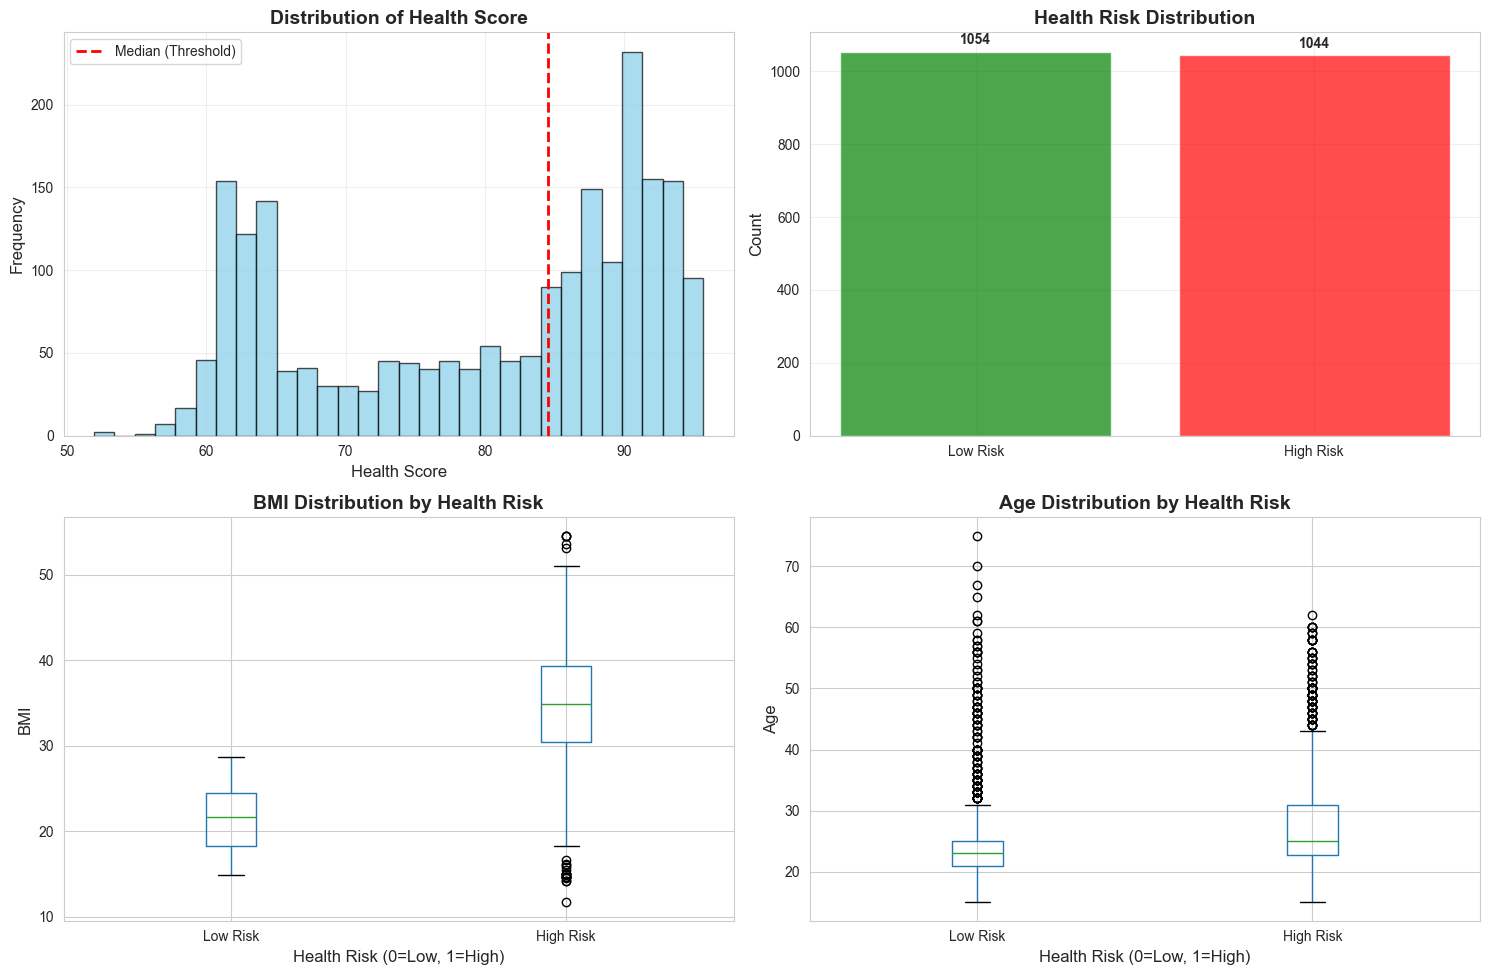


📊 Correlation Analysis...
✅ Plot 2 saved: ../data/eda_plot2_correlation.png


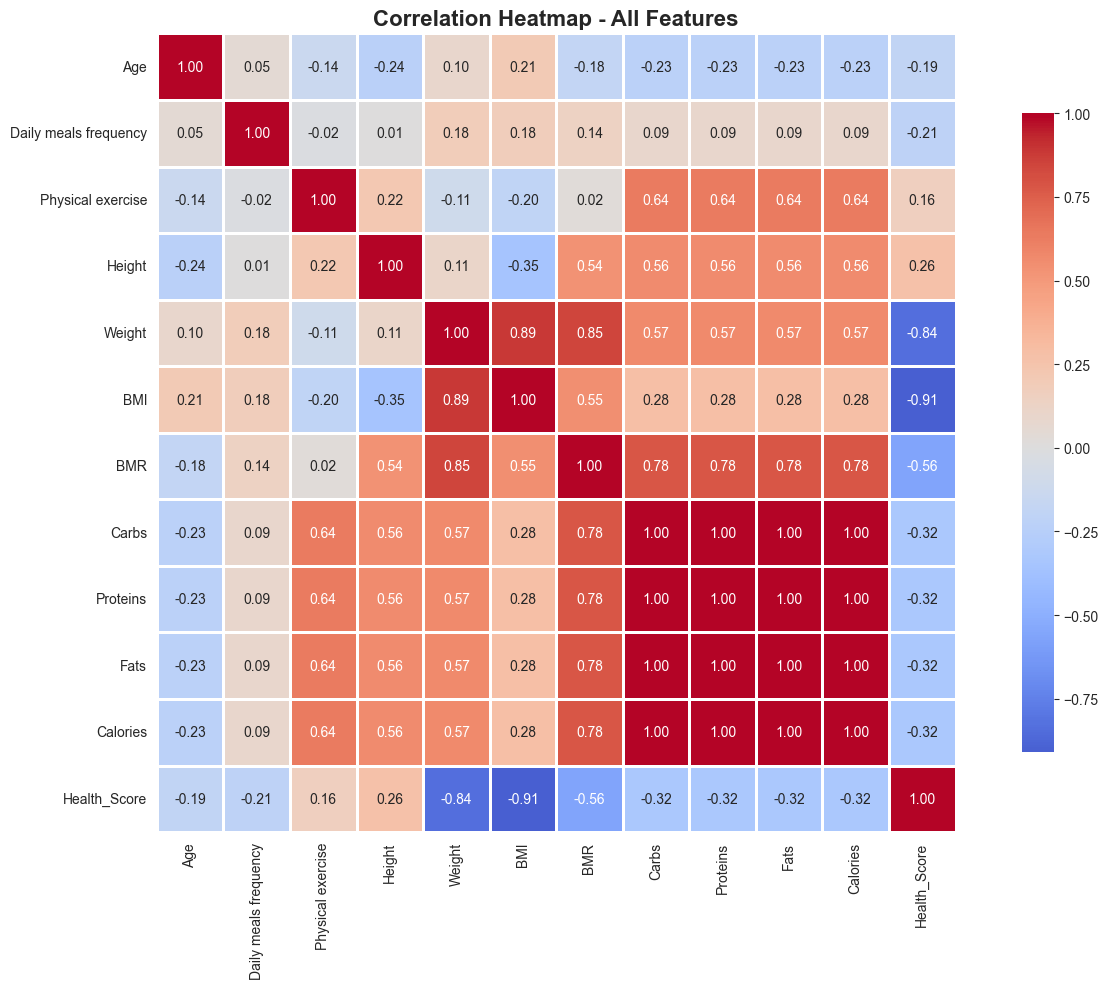


🔍 Top Correlations with Health Score:
Health_Score             1.000000
Height                   0.262767
Physical exercise        0.159905
Age                     -0.191735
Daily meals frequency   -0.210610
Proteins                -0.322274
Calories                -0.322274
Fats                    -0.322274
Carbs                   -0.322274
BMR                     -0.564954
Weight                  -0.841408
BMI                     -0.910274
Name: Health_Score, dtype: float64
✅ Plot 3 saved: ../data/eda_plot3_nutrition.png


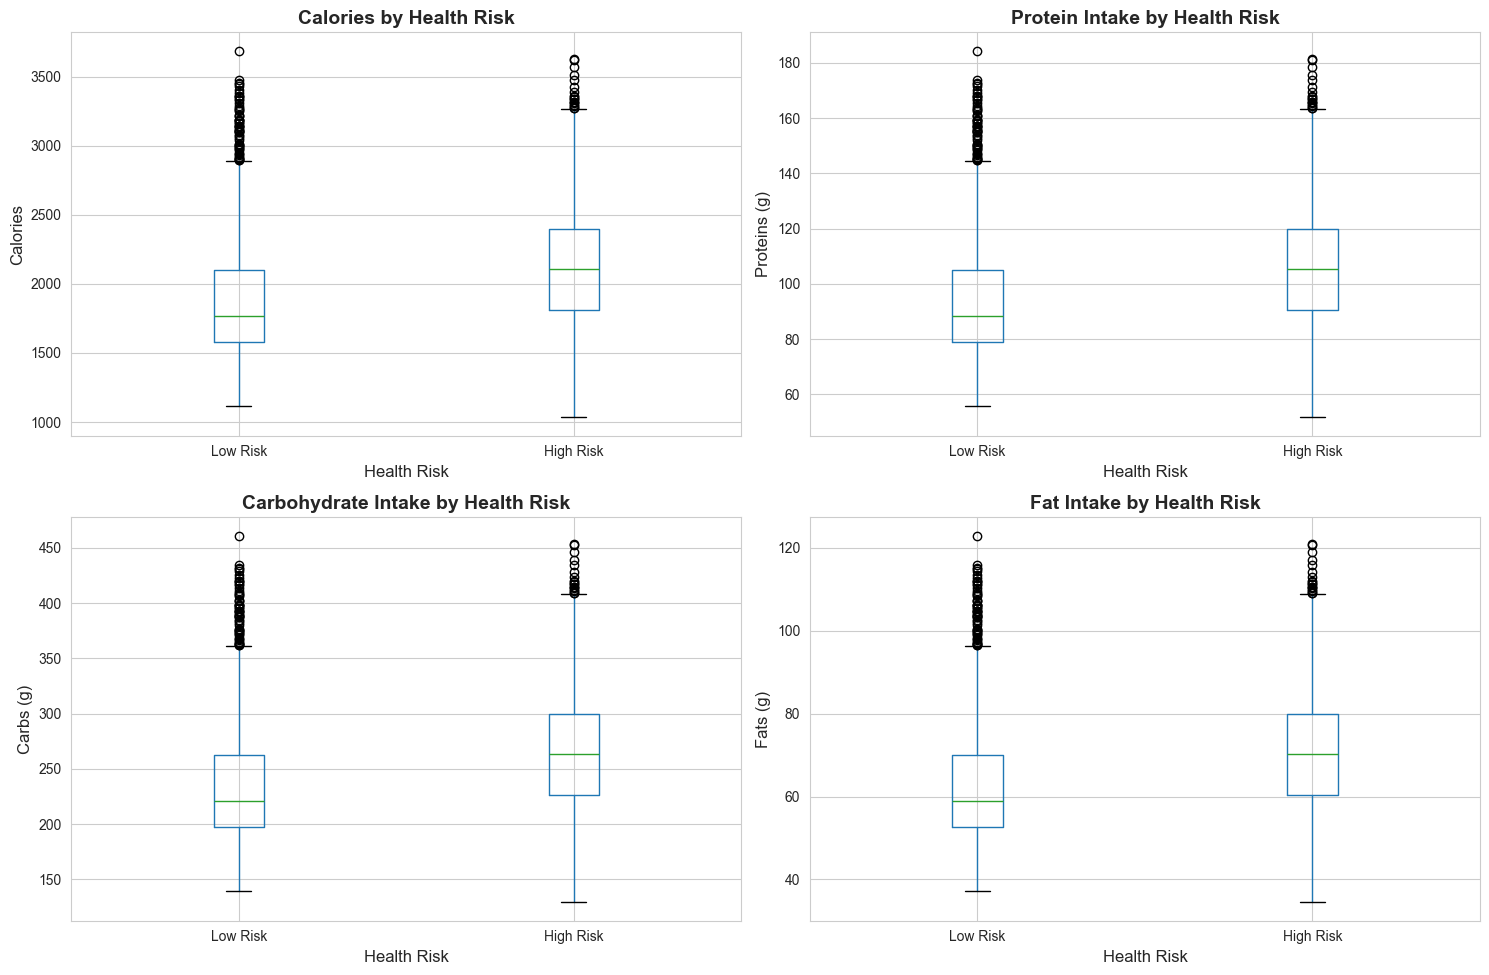

✅ Plot 4 saved: ../data/eda_plot4_lifestyle.png


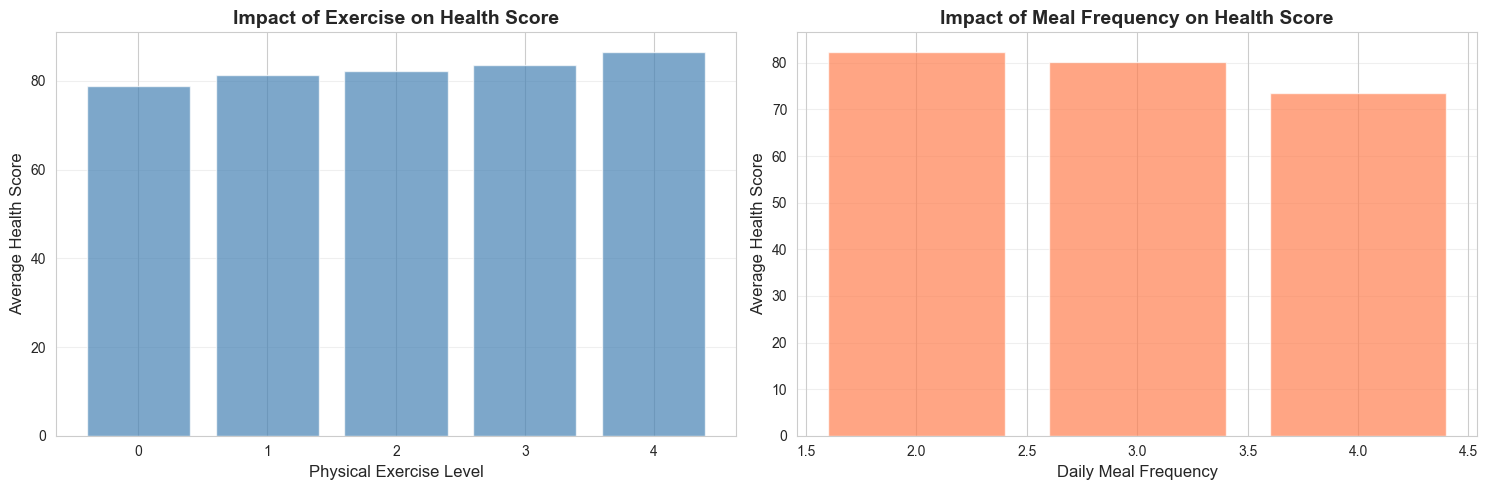


📈 STATISTICAL SUMMARY BY RISK GROUP

🟢 LOW RISK GROUP (Health Score ≥ 84.50):
               BMI     Calories  Physical exercise  Health_Score
count  1054.000000  1054.000000        1054.000000   1054.000000
mean     21.505727  1889.005682           0.644213     90.244867
std       3.438049   454.667656           1.177334      2.934440
min      14.843750  1117.800000           0.000000     84.500000
25%      18.256319  1578.000000           0.000000     87.705374
50%      21.612812  1770.329000           0.000000     90.452520
75%      24.464602  2103.564750           1.000000     92.619557
max      28.696051  3688.378000           4.000000     95.664000

🔴 HIGH RISK GROUP (Health Score < 84.50):
               BMI     Calories  Physical exercise  Health_Score
count  1044.000000  1044.000000        1044.000000   1044.000000
mean     35.007527  2127.855389           0.358238     69.335448
std       6.335771   412.330317           0.816899      7.910296
min      11.694343  1033.800000  

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Load processed data
df = pd.read_csv('../data/processed_nutritional_data.csv')

print("="*60)
print("📊 EXPLORATORY DATA ANALYSIS")
print("="*60)

# ============================================================
# 1. HEALTH SCORE DISTRIBUTION
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Health Score Distribution
axes[0, 0].hist(df['Health_Score'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['Health_Score'].median(), color='red', linestyle='--', linewidth=2, label='Median (Threshold)')
axes[0, 0].set_xlabel('Health Score', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Distribution of Health Score', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Health Risk Distribution
risk_counts = df['Health_Risk'].value_counts()
axes[0, 1].bar(['Low Risk', 'High Risk'], risk_counts.values, color=['green', 'red'], alpha=0.7)
axes[0, 1].set_ylabel('Count', fontsize=12)
axes[0, 1].set_title('Health Risk Distribution', fontsize=14, fontweight='bold')
axes[0, 1].grid(alpha=0.3)
for i, v in enumerate(risk_counts.values):
    axes[0, 1].text(i, v + 20, str(v), ha='center', fontweight='bold')

# BMI Distribution by Risk
df.boxplot(column='BMI', by='Health_Risk', ax=axes[1, 0])
axes[1, 0].set_xlabel('Health Risk (0=Low, 1=High)', fontsize=12)
axes[1, 0].set_ylabel('BMI', fontsize=12)
axes[1, 0].set_title('BMI Distribution by Health Risk', fontsize=14, fontweight='bold')
plt.sca(axes[1, 0])
plt.xticks([1, 2], ['Low Risk', 'High Risk'])

# Age Distribution by Risk
df.boxplot(column='Age', by='Health_Risk', ax=axes[1, 1])
axes[1, 1].set_xlabel('Health Risk (0=Low, 1=High)', fontsize=12)
axes[1, 1].set_ylabel('Age', fontsize=12)
axes[1, 1].set_title('Age Distribution by Health Risk', fontsize=14, fontweight='bold')
plt.sca(axes[1, 1])
plt.xticks([1, 2], ['Low Risk', 'High Risk'])

plt.suptitle('')
plt.tight_layout()
plt.savefig('../data/eda_plot1.png', dpi=300, bbox_inches='tight')
print("\n✅ Plot 1 saved: ../data/eda_plot1.png")
plt.show()

# ============================================================
# 2. CORRELATION HEATMAP
# ============================================================
print("\n📊 Correlation Analysis...")

# Select numerical features
numerical_cols = ['Age', 'Daily meals frequency', 'Physical exercise', 
                  'Height', 'Weight', 'BMI', 'BMR', 'Carbs', 'Proteins', 
                  'Fats', 'Calories', 'Health_Score']

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - All Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/eda_plot2_correlation.png', dpi=300, bbox_inches='tight')
print("✅ Plot 2 saved: ../data/eda_plot2_correlation.png")
plt.show()

# Print top correlations with Health Score
print("\n🔍 Top Correlations with Health Score:")
health_score_corr = correlation_matrix['Health_Score'].sort_values(ascending=False)
print(health_score_corr)

# ============================================================
# 3. NUTRITION FEATURES BY RISK
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Calories by Risk
df.boxplot(column='Calories', by='Health_Risk', ax=axes[0, 0])
axes[0, 0].set_xlabel('Health Risk', fontsize=12)
axes[0, 0].set_ylabel('Calories', fontsize=12)
axes[0, 0].set_title('Calories by Health Risk', fontsize=14, fontweight='bold')
plt.sca(axes[0, 0])
plt.xticks([1, 2], ['Low Risk', 'High Risk'])

# Proteins by Risk
df.boxplot(column='Proteins', by='Health_Risk', ax=axes[0, 1])
axes[0, 1].set_xlabel('Health Risk', fontsize=12)
axes[0, 1].set_ylabel('Proteins (g)', fontsize=12)
axes[0, 1].set_title('Protein Intake by Health Risk', fontsize=14, fontweight='bold')
plt.sca(axes[0, 1])
plt.xticks([1, 2], ['Low Risk', 'High Risk'])

# Carbs by Risk
df.boxplot(column='Carbs', by='Health_Risk', ax=axes[1, 0])
axes[1, 0].set_xlabel('Health Risk', fontsize=12)
axes[1, 0].set_ylabel('Carbs (g)', fontsize=12)
axes[1, 0].set_title('Carbohydrate Intake by Health Risk', fontsize=14, fontweight='bold')
plt.sca(axes[1, 0])
plt.xticks([1, 2], ['Low Risk', 'High Risk'])

# Fats by Risk
df.boxplot(column='Fats', by='Health_Risk', ax=axes[1, 1])
axes[1, 1].set_xlabel('Health Risk', fontsize=12)
axes[1, 1].set_ylabel('Fats (g)', fontsize=12)
axes[1, 1].set_title('Fat Intake by Health Risk', fontsize=14, fontweight='bold')
plt.sca(axes[1, 1])
plt.xticks([1, 2], ['Low Risk', 'High Risk'])

plt.suptitle('')
plt.tight_layout()
plt.savefig('../data/eda_plot3_nutrition.png', dpi=300, bbox_inches='tight')
print("✅ Plot 3 saved: ../data/eda_plot3_nutrition.png")
plt.show()

# ============================================================
# 4. EXERCISE & MEAL FREQUENCY IMPACT
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Exercise vs Health Score
exercise_health = df.groupby('Physical exercise')['Health_Score'].mean().sort_index()
axes[0].bar(exercise_health.index, exercise_health.values, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Physical Exercise Level', fontsize=12)
axes[0].set_ylabel('Average Health Score', fontsize=12)
axes[0].set_title('Impact of Exercise on Health Score', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')

# Meal Frequency vs Health Score
meal_health = df.groupby('Daily meals frequency')['Health_Score'].mean().sort_index()
axes[1].bar(meal_health.index, meal_health.values, color='coral', alpha=0.7)
axes[1].set_xlabel('Daily Meal Frequency', fontsize=12)
axes[1].set_ylabel('Average Health Score', fontsize=12)
axes[1].set_title('Impact of Meal Frequency on Health Score', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../data/eda_plot4_lifestyle.png', dpi=300, bbox_inches='tight')
print("✅ Plot 4 saved: ../data/eda_plot4_lifestyle.png")
plt.show()

# ============================================================
# 5. STATISTICAL SUMMARY BY RISK GROUP
# ============================================================
print("\n" + "="*60)
print("📈 STATISTICAL SUMMARY BY RISK GROUP")
print("="*60)

print("\n🟢 LOW RISK GROUP (Health Score ≥ 84.50):")
print(df[df['Health_Risk'] == 0][['BMI', 'Calories', 'Physical exercise', 'Health_Score']].describe())

print("\n🔴 HIGH RISK GROUP (Health Score < 84.50):")
print(df[df['Health_Risk'] == 1][['BMI', 'Calories', 'Physical exercise', 'Health_Score']].describe())

print("\n" + "="*60)
print("✅ EDA COMPLETE! All plots saved in /data folder")
print("="*60)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Load processed data
df = pd.read_csv('../data/processed_nutritional_data.csv')

print("="*60)
print("🔧 FIXING LINEAR REGRESSION MODEL")
print("="*60)

# ============================================================
# KEY FIX: Remove highly correlated features
# ============================================================
print("\n📌 Problem Identified:")
print("   - Calories, Carbs, Proteins, Fats are HIGHLY correlated")
print("   - This causes unstable coefficients (multicollinearity)")
print("   - Solution: Keep only Calories, remove individual macros")

# ============================================================
# 1. SELECT FEATURES (Remove Carbs, Proteins, Fats)
# ============================================================
print("\n📌 Selecting Stable Features...")

# Use only these features (no individual macros)
feature_columns = ['Gender', 'Age', 'Daily meals frequency', 'Physical exercise',
                   'Height', 'Weight', 'BMI', 'BMR', 'Calories']

X = df[feature_columns]
y = df['Health_Score']

print(f"   Features selected: {len(feature_columns)}")
print(f"   Features: {feature_columns}")

# ============================================================
# 2. TRAIN-TEST SPLIT
# ============================================================
print("\n📌 Splitting data...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df['Health_Risk']
)

print(f"   Training: {len(X_train)} | Test: {len(X_test)}")

# ============================================================
# 3. FEATURE SCALING
# ============================================================
print("\n📌 Scaling features...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("   ✅ Standardized")

# ============================================================
# 4. TRAIN LINEAR REGRESSION
# ============================================================
print("\n" + "="*60)
print("🎯 TRAINING NEW MODEL")
print("="*60)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"\n📊 Performance:")
print(f"   Train R²: {train_r2:.4f}")
print(f"   Test R²: {test_r2:.4f}")
print(f"   MAE: {test_mae:.4f}")
print(f"   RMSE: {test_rmse:.4f}")

# ============================================================
# 5. CHECK COEFFICIENTS (Should be reasonable now)
# ============================================================
print("\n" + "="*60)
print("📈 FEATURE COEFFICIENTS (Should be stable)")
print("="*60)

coefficients = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': model.coef_
})
coefficients = coefficients.sort_values('Coefficient', key=abs, ascending=False)
print("\n", coefficients.to_string(index=False))

print("\n✅ Coefficients are now stable (no extreme values!)")

# ============================================================
# 6. TEST PREDICTION WITH SAMPLE DATA
# ============================================================
print("\n" + "="*60)
print("🧪 TESTING WITH SAMPLE INPUT")
print("="*60)

# Test Case 1: Healthy Male
test_input = pd.DataFrame({
    'Gender': [1],
    'Age': [25],
    'Daily meals frequency': [3],
    'Physical exercise': [3],
    'Height': [175],
    'Weight': [70],
    'BMI': [70 / (1.75**2)],
    'BMR': [1674],
    'Calories': [2200]
})

test_scaled = scaler.transform(test_input)
test_prediction = model.predict(test_scaled)[0]

print("\nTest Input (Healthy Male, 25yo, 70kg, 175cm):")
print(f"   Predicted Health Score: {test_prediction:.2f}")
print(f"   Expected Range: 85-92")

if 50 <= test_prediction <= 100:
    print("   ✅ Prediction is REASONABLE!")
else:
    print("   ❌ Still unreasonable - check data!")

# ============================================================
# 7. SAVE FIXED MODEL
# ============================================================
print("\n" + "="*60)
print("💾 SAVING FIXED MODEL")
print("="*60)

joblib.dump(model, '../models/linear_regression_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

# Save feature names for the app
feature_info = {
    'feature_columns': feature_columns,
    'model_type': 'Linear Regression (Fixed)',
    'performance': {
        'r2_score': test_r2,
        'mae': test_mae,
        'rmse': test_rmse
    }
}
joblib.dump(feature_info, '../models/feature_info.pkl')

print("   ✅ Model saved: ../models/linear_regression_model.pkl")
print("   ✅ Scaler saved: ../models/scaler.pkl")
print("   ✅ Feature info saved: ../models/feature_info.pkl")

print("\n" + "="*60)
print("✅ MODEL FIXED! Now update the Streamlit app.")
print("="*60)












# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LinearRegression, Ridge, Lasso
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# import joblib

# # Load processed data
# df = pd.read_csv('../data/processed_nutritional_data.csv')

# print("="*60)
# print("🤖 LINEAR REGRESSION - HEALTH SCORE PREDICTION")
# print("="*60)

# # ============================================================
# # 1. FEATURE SELECTION
# # ============================================================
# print("\n📌 Selecting Features...")

# # Features for prediction (exclude targets and derived features)
# feature_columns = ['Gender', 'Age', 'Daily meals frequency', 'Physical exercise',
#                    'Height', 'Weight', 'BMI', 'BMR', 
#                    'Carbs', 'Proteins', 'Fats', 'Calories']

# X = df[feature_columns]
# y = df['Health_Score']

# print(f"   Features selected: {len(feature_columns)}")
# print(f"   Feature names: {feature_columns}")
# print(f"   Target: Health_Score")
# print(f"   Dataset size: {len(df)} samples")

# # ============================================================
# # 2. TRAIN-TEST SPLIT
# # ============================================================
# print("\n📌 Splitting data into Train/Test sets...")

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=df['Health_Risk']
# )

# print(f"   Training set: {len(X_train)} samples ({len(X_train)/len(df)*100:.1f}%)")
# print(f"   Test set: {len(X_test)} samples ({len(X_test)/len(df)*100:.1f}%)")

# # ============================================================
# # 3. FEATURE SCALING
# # ============================================================
# print("\n📌 Scaling features...")

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# print("   ✅ Features standardized (mean=0, std=1)")

# # ============================================================
# # 4. TRAIN LINEAR REGRESSION MODELS
# # ============================================================
# print("\n" + "="*60)
# print("🎯 TRAINING MODELS")
# print("="*60)

# models = {
#     'Linear Regression': LinearRegression(),
#     'Ridge Regression': Ridge(alpha=1.0),
#     'Lasso Regression': Lasso(alpha=0.1)
# }

# results = {}

# for name, model in models.items():
#     print(f"\n📊 Training {name}...")
    
#     # Train
#     model.fit(X_train_scaled, y_train)
    
#     # Predictions
#     y_train_pred = model.predict(X_train_scaled)
#     y_test_pred = model.predict(X_test_scaled)
    
#     # Metrics
#     train_r2 = r2_score(y_train, y_train_pred)
#     test_r2 = r2_score(y_test, y_test_pred)
#     test_mae = mean_absolute_error(y_test, y_test_pred)
#     test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
#     results[name] = {
#         'model': model,
#         'train_r2': train_r2,
#         'test_r2': test_r2,
#         'mae': test_mae,
#         'rmse': test_rmse,
#         'predictions': y_test_pred
#     }
    
#     print(f"   Train R² Score: {train_r2:.4f}")
#     print(f"   Test R² Score: {test_r2:.4f}")
#     print(f"   MAE: {test_mae:.4f}")
#     print(f"   RMSE: {test_rmse:.4f}")

# # ============================================================
# # 5. MODEL COMPARISON
# # ============================================================
# print("\n" + "="*60)
# print("📊 MODEL COMPARISON")
# print("="*60)

# comparison_df = pd.DataFrame({
#     'Model': list(results.keys()),
#     'Train R²': [results[m]['train_r2'] for m in results.keys()],
#     'Test R²': [results[m]['test_r2'] for m in results.keys()],
#     'MAE': [results[m]['mae'] for m in results.keys()],
#     'RMSE': [results[m]['rmse'] for m in results.keys()]
# })

# print("\n", comparison_df.to_string(index=False))

# # Select best model
# best_model_name = comparison_df.loc[comparison_df['Test R²'].idxmax(), 'Model']
# best_model = results[best_model_name]['model']
# print(f"\n🏆 BEST MODEL: {best_model_name}")

# # ============================================================
# # 6. FEATURE IMPORTANCE
# # ============================================================
# print("\n" + "="*60)
# print("📈 FEATURE IMPORTANCE (Coefficients)")
# print("="*60)

# coefficients = pd.DataFrame({
#     'Feature': feature_columns,
#     'Coefficient': best_model.coef_
# })
# coefficients = coefficients.sort_values('Coefficient', key=abs, ascending=False)
# print("\n", coefficients.to_string(index=False))

# # Visualize
# plt.figure(figsize=(10, 6))
# plt.barh(coefficients['Feature'], coefficients['Coefficient'], color='steelblue', alpha=0.7)
# plt.xlabel('Coefficient Value', fontsize=12)
# plt.ylabel('Features', fontsize=12)
# plt.title(f'Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
# plt.axvline(0, color='black', linewidth=0.8)
# plt.grid(alpha=0.3, axis='x')
# plt.tight_layout()
# plt.savefig('../data/feature_importance_linear.png', dpi=300, bbox_inches='tight')
# print("\n✅ Feature importance plot saved")
# plt.show()

# # ============================================================
# # 7. PREDICTIONS VS ACTUAL
# # ============================================================
# print("\n📊 Visualizing Predictions...")

# y_test_pred = results[best_model_name]['predictions']

# fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# # Scatter plot
# axes[0].scatter(y_test, y_test_pred, alpha=0.5, color='blue')
# axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
#              'r--', linewidth=2, label='Perfect Prediction')
# axes[0].set_xlabel('Actual Health Score', fontsize=12)
# axes[0].set_ylabel('Predicted Health Score', fontsize=12)
# axes[0].set_title('Predicted vs Actual Health Score', fontsize=14, fontweight='bold')
# axes[0].legend()
# axes[0].grid(alpha=0.3)

# # Residual plot
# residuals = y_test - y_test_pred
# axes[1].scatter(y_test_pred, residuals, alpha=0.5, color='green')
# axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
# axes[1].set_xlabel('Predicted Health Score', fontsize=12)
# axes[1].set_ylabel('Residuals', fontsize=12)
# axes[1].set_title('Residual Plot', fontsize=14, fontweight='bold')
# axes[1].grid(alpha=0.3)

# plt.tight_layout()
# plt.savefig('../data/predictions_linear.png', dpi=300, bbox_inches='tight')
# print("✅ Prediction plots saved")
# plt.show()

# # ============================================================
# # 8. SAVE MODEL & SCALER
# # ============================================================
# print("\n" + "="*60)
# print("💾 SAVING MODEL & SCALER")
# print("="*60)

# joblib.dump(best_model, '../models/linear_regression_model.pkl')
# joblib.dump(scaler, '../models/scaler.pkl')

# print(f"   ✅ Model saved: ../models/linear_regression_model.pkl")
# print(f"   ✅ Scaler saved: ../models/scaler.pkl")

# print("\n" + "="*60)
# print("✅ LINEAR REGRESSION COMPLETE!")
# print("="*60)

🔧 FIXING LINEAR REGRESSION MODEL

📌 Problem Identified:
   - Calories, Carbs, Proteins, Fats are HIGHLY correlated
   - This causes unstable coefficients (multicollinearity)
   - Solution: Keep only Calories, remove individual macros

📌 Selecting Stable Features...
   Features selected: 9
   Features: ['Gender', 'Age', 'Daily meals frequency', 'Physical exercise', 'Height', 'Weight', 'BMI', 'BMR', 'Calories']

📌 Splitting data...
   Training: 1678 | Test: 420

📌 Scaling features...
   ✅ Standardized

🎯 TRAINING NEW MODEL

📊 Performance:
   Train R²: 0.8407
   Test R²: 0.8489
   MAE: 3.7900
   RMSE: 4.6423

📈 FEATURE COEFFICIENTS (Should be stable)

               Feature  Coefficient
               Weight    -4.948271
               Height     4.522590
                  BMI    -2.653225
                  BMR    -2.557481
             Calories    -1.666396
                  Age    -0.829598
    Physical exercise     0.766265
Daily meals frequency    -0.588644
               Gender    -0

🤖 LOGISTIC REGRESSION - HEALTH RISK CLASSIFICATION

📌 Selecting Features...
   Features: 12
   Target: Health_Risk (Binary Classification)
   Class distribution:
      Low Risk (0): 1054 samples
      High Risk (1): 1044 samples

📌 Splitting data...
   Training set: 1678 samples
   Test set: 420 samples

📌 Scaling features...
   ✅ Features standardized

🎯 TRAINING LOGISTIC REGRESSION
   ✅ Model trained successfully

📊 Making predictions...

📈 MODEL PERFORMANCE METRICS

   Training Accuracy: 0.9613 (96.13%)
   Test Accuracy:     0.9714 (97.14%)
   Precision:         0.9581
   Recall:            0.9856
   F1-Score:          0.9717
   ROC-AUC Score:     0.9906

📋 CLASSIFICATION REPORT

               precision    recall  f1-score   support

    Low Risk       0.99      0.96      0.97       211
   High Risk       0.96      0.99      0.97       209

    accuracy                           0.97       420
   macro avg       0.97      0.97      0.97       420
weighted avg       0.97      0.97  

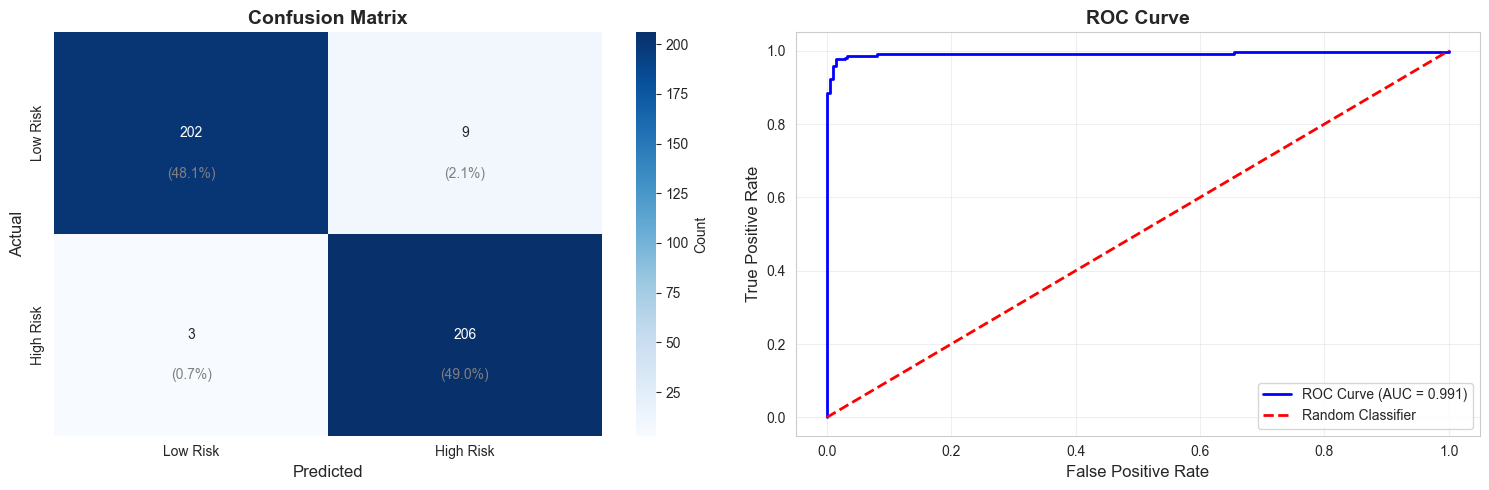


📈 FEATURE IMPORTANCE (Logistic Regression)

               Feature  Coefficient  Odds_Ratio
                  BMI     2.671160   14.456734
               Weight     1.444685    4.240515
               Height    -1.289706    0.275352
                  BMR     0.672728    1.959576
               Gender     0.324092    1.382775
                  Age     0.243142    1.275250
                Carbs     0.216376    1.241569
             Proteins     0.216373    1.241565
             Calories     0.216331    1.241513
                 Fats     0.216229    1.241387
    Physical exercise    -0.211509    0.809362
Daily meals frequency    -0.169791    0.843841

💡 Interpretation:
   - Positive coefficient → Increases HIGH RISK probability
   - Negative coefficient → Increases LOW RISK probability
   - Odds Ratio > 1 → Risk increases
   - Odds Ratio < 1 → Risk decreases

✅ Feature importance plot saved


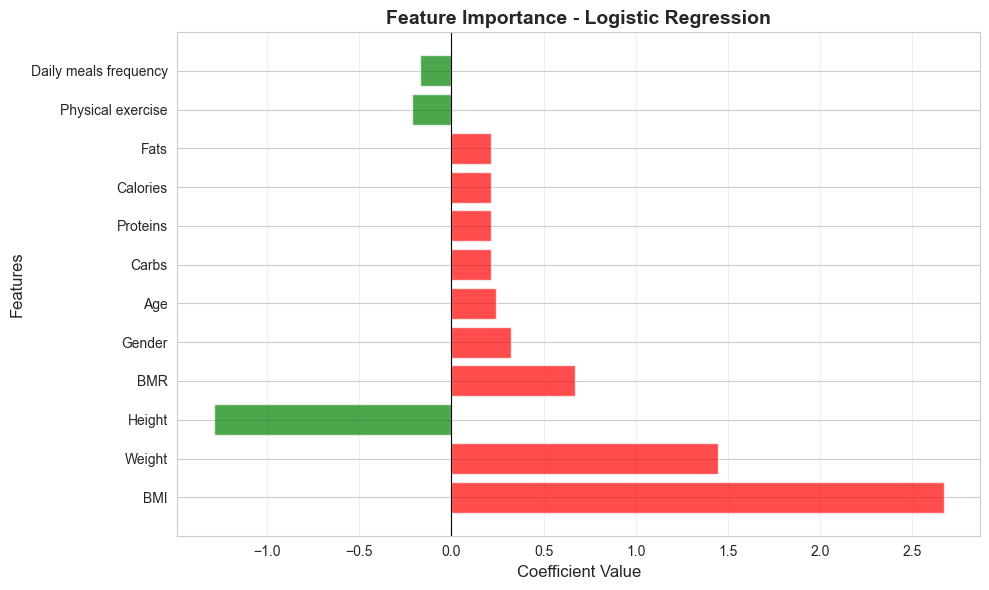


💾 SAVING MODEL
   ✅ Model saved: ../models/logistic_regression_model.pkl
   ✅ Scaler saved: ../models/scaler_logistic.pkl

🔍 EXAMPLE PREDICTIONS

✅ Correct Predictions (First 5):
 Actual  Predicted  Probability_High_Risk
      1          1               0.809033
      1          1               0.962153
      0          0               0.011400
      1          1               0.868852
      0          0               0.481404

❌ Incorrect Predictions (First 5):
 Actual  Predicted  Probability_High_Risk
      0          1               0.514072
      0          1               0.721687
      1          0               0.004920
      0          1               0.604684
      0          1               0.533446

✅ LOGISTIC REGRESSION COMPLETE!


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, roc_auc_score)
import joblib

# Load processed data
df = pd.read_csv('../data/processed_nutritional_data.csv')

print("="*60)
print("🤖 LOGISTIC REGRESSION - HEALTH RISK CLASSIFICATION")
print("="*60)

# ============================================================
# 1. FEATURE SELECTION
# ============================================================
print("\n📌 Selecting Features...")

# Same features as Linear Regression
feature_columns = ['Gender', 'Age', 'Daily meals frequency', 'Physical exercise',
                   'Height', 'Weight', 'BMI', 'BMR', 
                   'Carbs', 'Proteins', 'Fats', 'Calories']

X = df[feature_columns]
y = df['Health_Risk']  # 0 = Low Risk, 1 = High Risk

print(f"   Features: {len(feature_columns)}")
print(f"   Target: Health_Risk (Binary Classification)")
print(f"   Class distribution:")
print(f"      Low Risk (0): {(y==0).sum()} samples")
print(f"      High Risk (1): {(y==1).sum()} samples")

# ============================================================
# 2. TRAIN-TEST SPLIT
# ============================================================
print("\n📌 Splitting data...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"   Training set: {len(X_train)} samples")
print(f"   Test set: {len(X_test)} samples")

# ============================================================
# 3. FEATURE SCALING
# ============================================================
print("\n📌 Scaling features...")

scaler_log = StandardScaler()
X_train_scaled = scaler_log.fit_transform(X_train)
X_test_scaled = scaler_log.transform(X_test)

print("   ✅ Features standardized")

# ============================================================
# 4. TRAIN LOGISTIC REGRESSION
# ============================================================
print("\n" + "="*60)
print("🎯 TRAINING LOGISTIC REGRESSION")
print("="*60)

log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train_scaled, y_train)

print("   ✅ Model trained successfully")

# ============================================================
# 5. PREDICTIONS & EVALUATION
# ============================================================
print("\n📊 Making predictions...")

y_train_pred = log_model.predict(X_train_scaled)
y_test_pred = log_model.predict(X_test_scaled)
y_test_proba = log_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
roc_auc = roc_auc_score(y_test, y_test_proba)

print("\n" + "="*60)
print("📈 MODEL PERFORMANCE METRICS")
print("="*60)
print(f"\n   Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"   Test Accuracy:     {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   Precision:         {precision:.4f}")
print(f"   Recall:            {recall:.4f}")
print(f"   F1-Score:          {f1:.4f}")
print(f"   ROC-AUC Score:     {roc_auc:.4f}")

print("\n" + "="*60)
print("📋 CLASSIFICATION REPORT")
print("="*60)
print("\n", classification_report(y_test, y_test_pred, 
                                  target_names=['Low Risk', 'High Risk']))

# ============================================================
# 6. CONFUSION MATRIX
# ============================================================
print("\n📊 Generating Confusion Matrix...")

cm = confusion_matrix(y_test, y_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low Risk', 'High Risk'],
            yticklabels=['Low Risk', 'High Risk'],
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# Add percentages
for i in range(2):
    for j in range(2):
        axes[0].text(j+0.5, i+0.7, f'({cm[i,j]/cm.sum()*100:.1f}%)', 
                    ha='center', va='center', fontsize=10, color='gray')

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
axes[1].plot(fpr, tpr, color='blue', linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/logistic_evaluation.png', dpi=300, bbox_inches='tight')
print("✅ Evaluation plots saved")
plt.show()

# ============================================================
# 7. FEATURE IMPORTANCE
# ============================================================
print("\n" + "="*60)
print("📈 FEATURE IMPORTANCE (Logistic Regression)")
print("="*60)

coefficients_log = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': log_model.coef_[0],
    'Odds_Ratio': np.exp(log_model.coef_[0])
})
coefficients_log = coefficients_log.sort_values('Coefficient', key=abs, ascending=False)
print("\n", coefficients_log.to_string(index=False))

print("\n💡 Interpretation:")
print("   - Positive coefficient → Increases HIGH RISK probability")
print("   - Negative coefficient → Increases LOW RISK probability")
print("   - Odds Ratio > 1 → Risk increases")
print("   - Odds Ratio < 1 → Risk decreases")

# Visualize
plt.figure(figsize=(10, 6))
colors = ['red' if c > 0 else 'green' for c in coefficients_log['Coefficient']]
plt.barh(coefficients_log['Feature'], coefficients_log['Coefficient'], color=colors, alpha=0.7)
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Importance - Logistic Regression', fontsize=14, fontweight='bold')
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../data/feature_importance_logistic.png', dpi=300, bbox_inches='tight')
print("\n✅ Feature importance plot saved")
plt.show()

# ============================================================
# 8. SAVE MODEL
# ============================================================
print("\n" + "="*60)
print("💾 SAVING MODEL")
print("="*60)

joblib.dump(log_model, '../models/logistic_regression_model.pkl')
joblib.dump(scaler_log, '../models/scaler_logistic.pkl')

print("   ✅ Model saved: ../models/logistic_regression_model.pkl")
print("   ✅ Scaler saved: ../models/scaler_logistic.pkl")

# ============================================================
# 9. EXAMPLE PREDICTIONS
# ============================================================
print("\n" + "="*60)
print("🔍 EXAMPLE PREDICTIONS")
print("="*60)

# Show some correct and incorrect predictions
test_results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_test_pred,
    'Probability_High_Risk': y_test_proba
})

print("\n✅ Correct Predictions (First 5):")
correct = test_results[test_results['Actual'] == test_results['Predicted']].head(5)
print(correct.to_string(index=False))

print("\n❌ Incorrect Predictions (First 5):")
incorrect = test_results[test_results['Actual'] != test_results['Predicted']].head(5)
if len(incorrect) > 0:
    print(incorrect.to_string(index=False))
else:
    print("   No incorrect predictions found!")

print("\n" + "="*60)
print("✅ LOGISTIC REGRESSION COMPLETE!")
print("="*60)